In [25]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.neighbors import NearestNeighbors
from scipy.spatial.distance import cdist
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
import joblib
import warnings

warnings.filterwarnings('ignore')

df = pd.read_csv(r"CC GENERAL.csv")

In [26]:
display(df.shape)

(8950, 18)

In [27]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

None

In [28]:
display(df.describe())

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000,8637.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.815725,2895.063757,2372.446607,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,169.123707,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,825.485459,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


In [29]:
display(df.isnull().sum())

CUST_ID                               0
BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64

In [30]:
display(df.duplicated().sum())

np.int64(0)

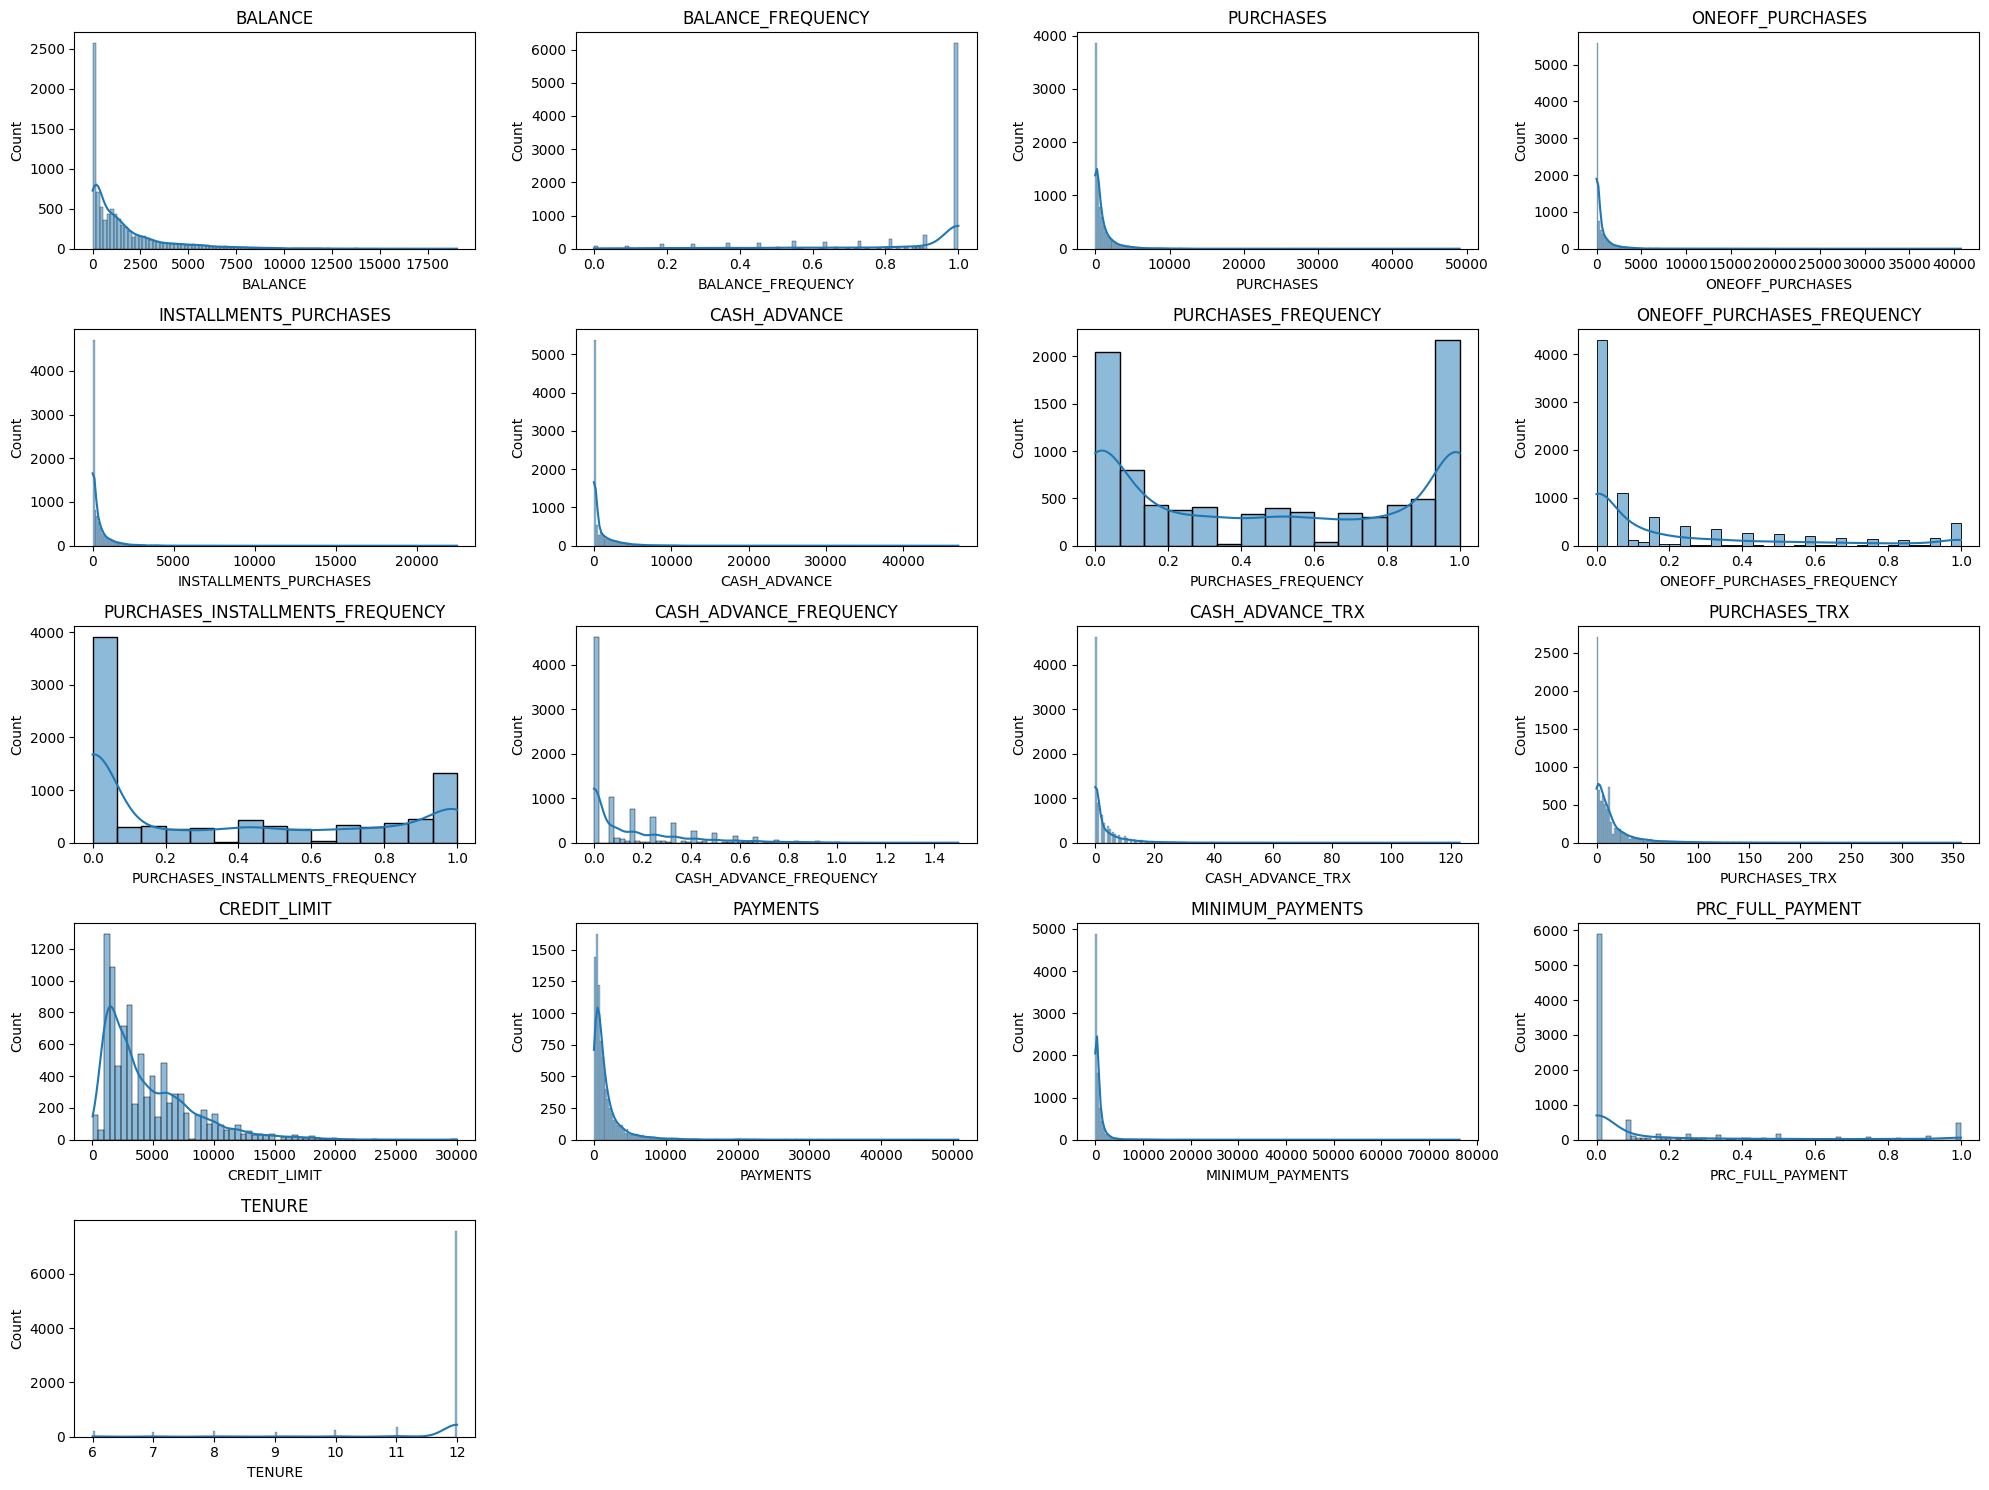

In [31]:
plt.figure(figsize=(20, 15))
numeric_cols = df.select_dtypes(include=np.number).columns
for i, col in enumerate(numeric_cols):
    plt.subplot(5, 4, i+1)
    sns.histplot(df[col], kde=True)
    plt.title(col)
plt.tight_layout()
plt.show()

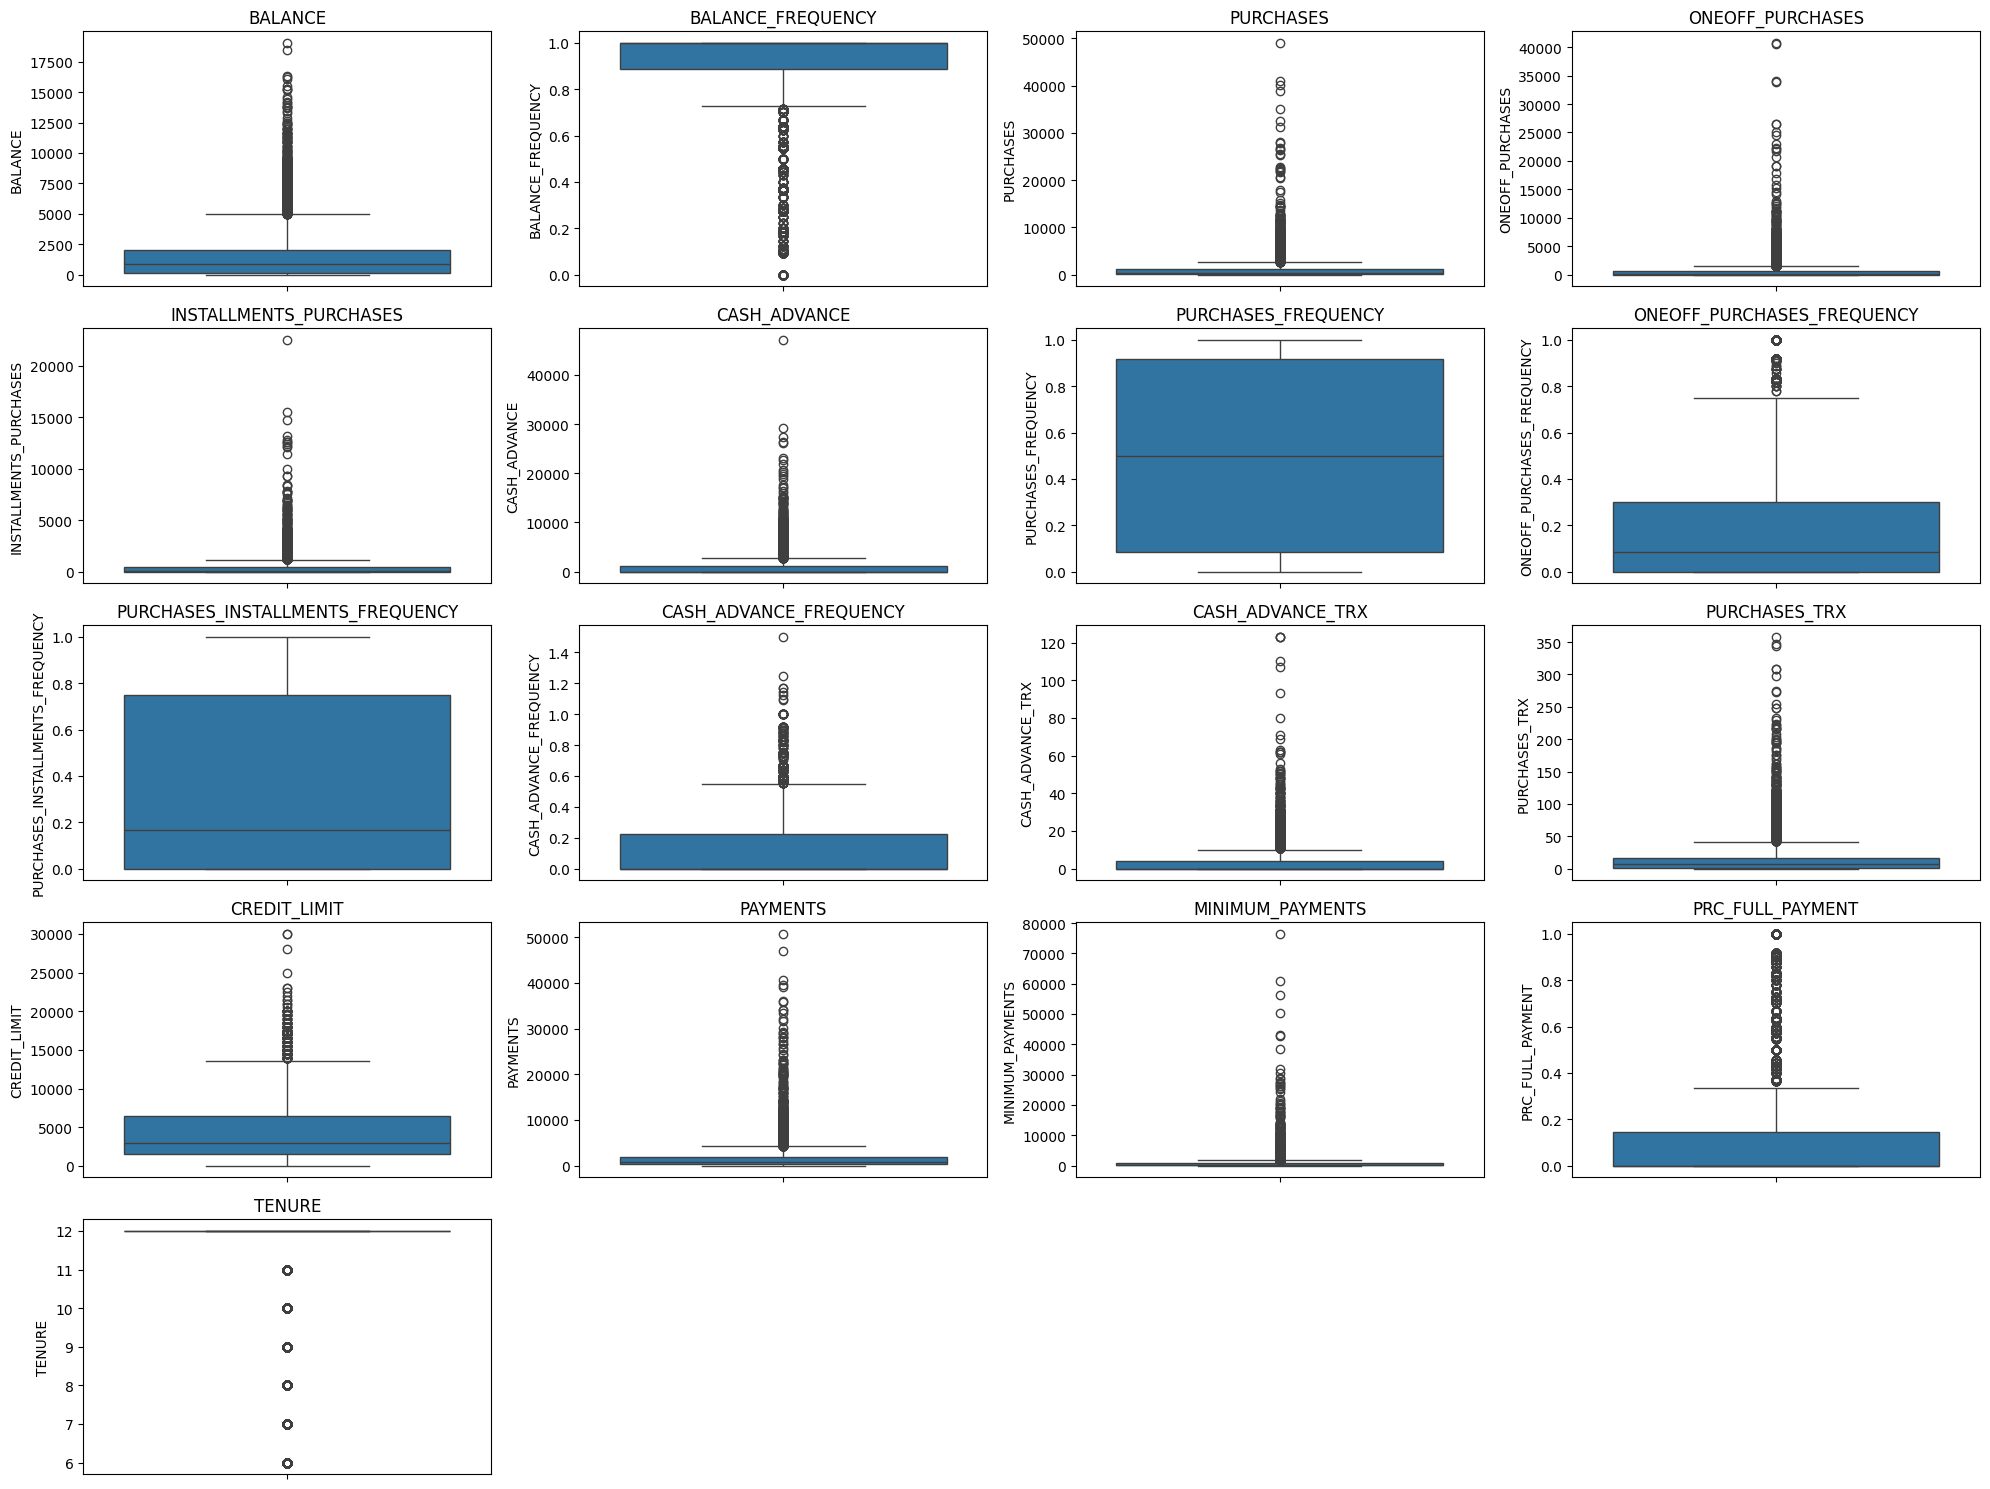

In [32]:
plt.figure(figsize=(20, 15))
for i, col in enumerate(numeric_cols):
    plt.subplot(5, 4, i+1)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

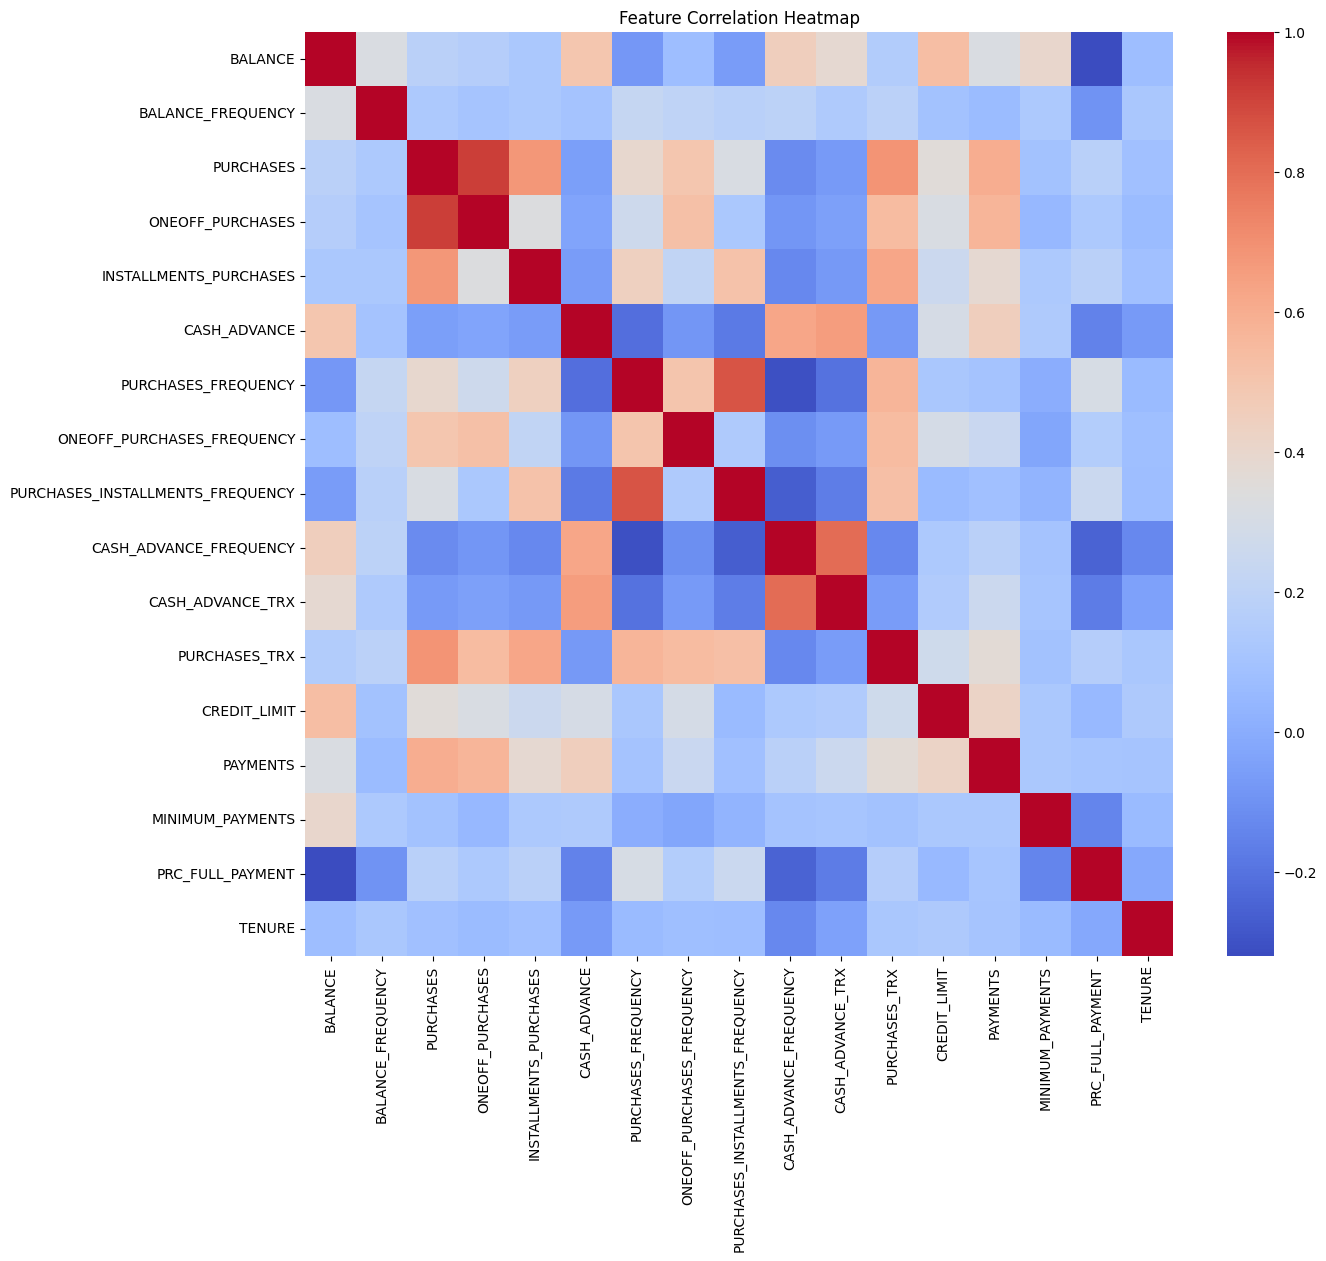

In [33]:
plt.figure(figsize=(14, 12))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=False, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

In [34]:
display(df.select_dtypes(include=np.number).skew())

BALANCE                              2.393386
BALANCE_FREQUENCY                   -2.023266
PURCHASES                            8.144269
ONEOFF_PURCHASES                    10.045083
INSTALLMENTS_PURCHASES               7.299120
CASH_ADVANCE                         5.166609
PURCHASES_FREQUENCY                  0.060164
ONEOFF_PURCHASES_FREQUENCY           1.535613
PURCHASES_INSTALLMENTS_FREQUENCY     0.509201
CASH_ADVANCE_FREQUENCY               1.828686
CASH_ADVANCE_TRX                     5.721298
PURCHASES_TRX                        4.630655
CREDIT_LIMIT                         1.522464
PAYMENTS                             5.907620
MINIMUM_PAYMENTS                    13.622797
PRC_FULL_PAYMENT                     1.942820
TENURE                              -2.943017
dtype: float64

In [35]:
customer_ids = df['CUST_ID']
df_features = df.drop('CUST_ID', axis=1)

for col in df_features.columns:
    df_features[col] = df_features[col].fillna(df_features[col].median())

def cap_outliers_iqr(dataframe):
    df_capped = dataframe.copy()
    for col in df_capped.columns:
        Q1 = df_capped[col].quantile(0.25)
        Q3 = df_capped[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df_capped[col] = np.where(df_capped[col] > upper_bound, upper_bound,
                         np.where(df_capped[col] < lower_bound, lower_bound, df_capped[col]))
    return df_capped

df_cleaned = cap_outliers_iqr(df_features)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cleaned)
df_scaled = pd.DataFrame(X_scaled, columns=df_cleaned.columns)

df_cleaned.to_csv('processed_data.csv', index=False)

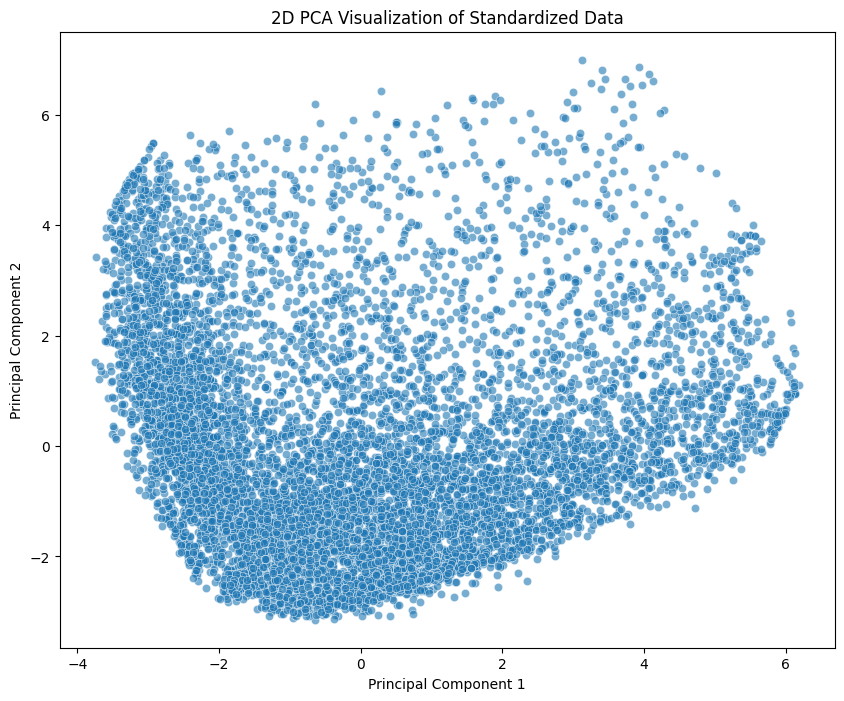

In [36]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
df_pca = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
df_pca.to_csv('pca_2d.csv', index=False)

plt.figure(figsize=(10, 8))
sns.scatterplot(x='PC1', y='PC2', data=df_pca, alpha=0.6)
plt.title("2D PCA Visualization of Standardized Data")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

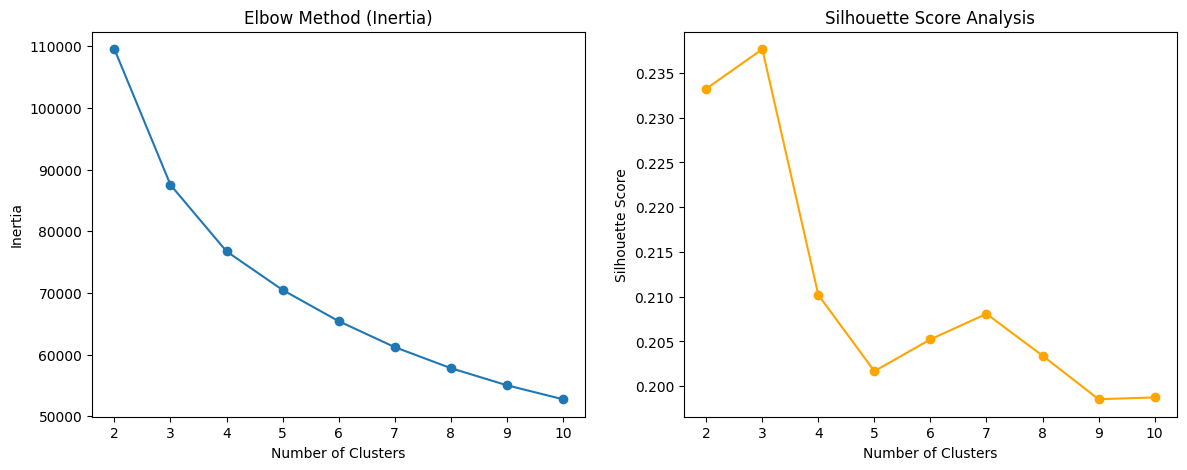

In [37]:
inertias = []
sil_scores = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(K_range, inertias, marker='o')
plt.title("Elbow Method (Inertia)")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")

plt.subplot(1, 2, 2)
plt.plot(K_range, sil_scores, marker='o', color='orange')
plt.title("Silhouette Score Analysis")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.show()

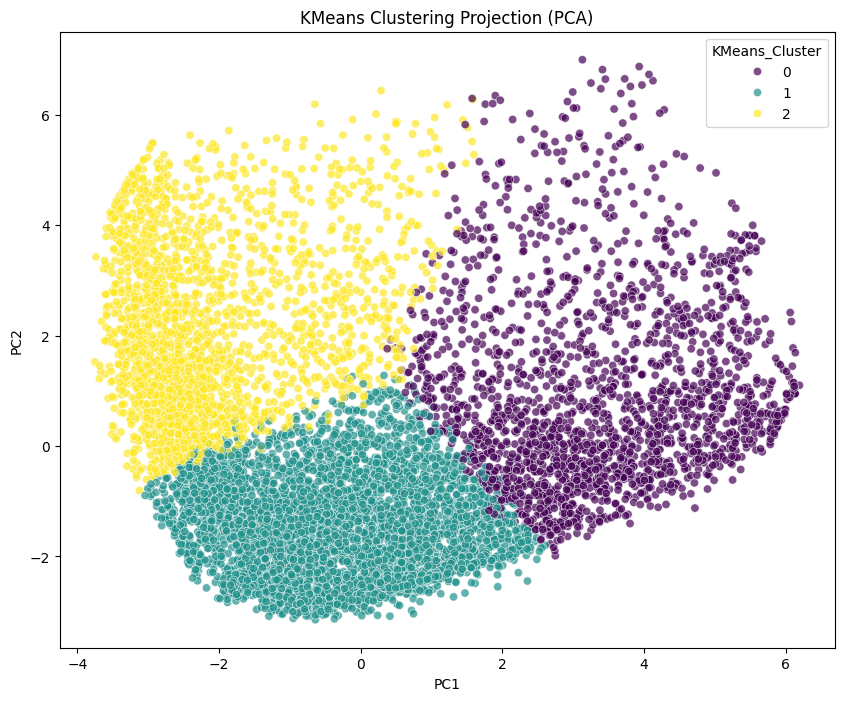

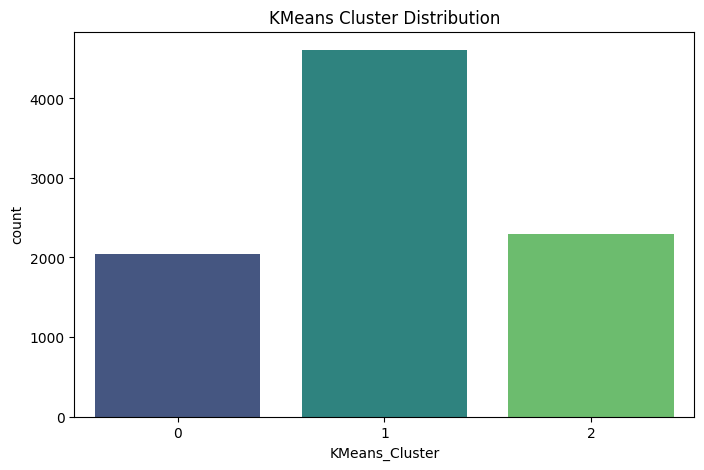

In [38]:
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df_pca['KMeans_Cluster'] = kmeans.fit_predict(X_scaled)

plt.figure(figsize=(10, 8))
sns.scatterplot(x='PC1', y='PC2', hue='KMeans_Cluster', palette='viridis', data=df_pca, alpha=0.7)
plt.title("KMeans Clustering Projection (PCA)")
plt.show()

plt.figure(figsize=(8, 5))
sns.countplot(x='KMeans_Cluster', data=df_pca, palette='viridis')
plt.title("KMeans Cluster Distribution")
plt.show()

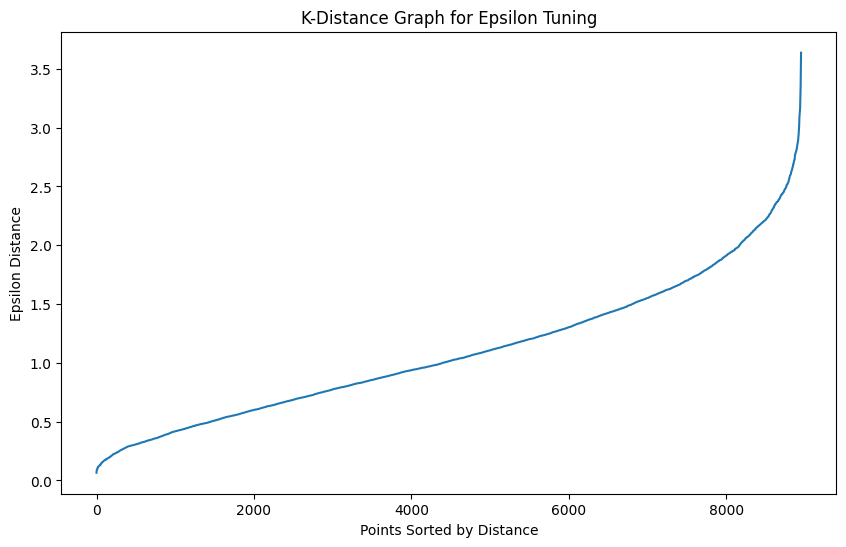

In [39]:
neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)
distances = np.sort(distances[:, 4], axis=0)

plt.figure(figsize=(10, 6))
plt.plot(distances)
plt.title("K-Distance Graph for Epsilon Tuning")
plt.ylabel("Epsilon Distance")
plt.xlabel("Points Sorted by Distance")
plt.show()

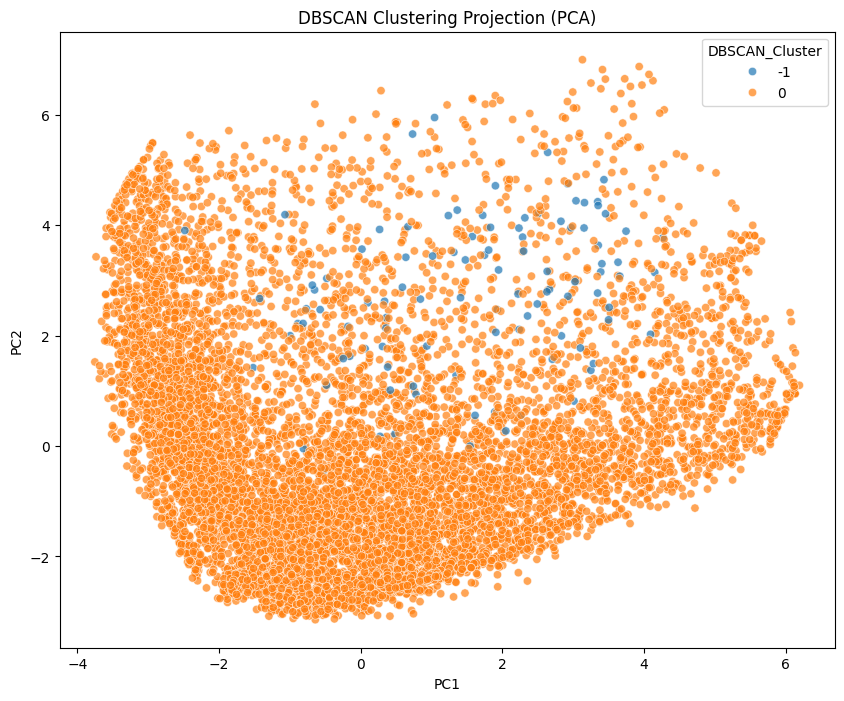

In [40]:
dbscan = DBSCAN(eps=2.5, min_samples=10)
df_pca['DBSCAN_Cluster'] = dbscan.fit_predict(X_scaled)

plt.figure(figsize=(10, 8))
sns.scatterplot(x='PC1', y='PC2', hue='DBSCAN_Cluster', palette='tab10', data=df_pca, alpha=0.7)
plt.title("DBSCAN Clustering Projection (PCA)")
plt.show()

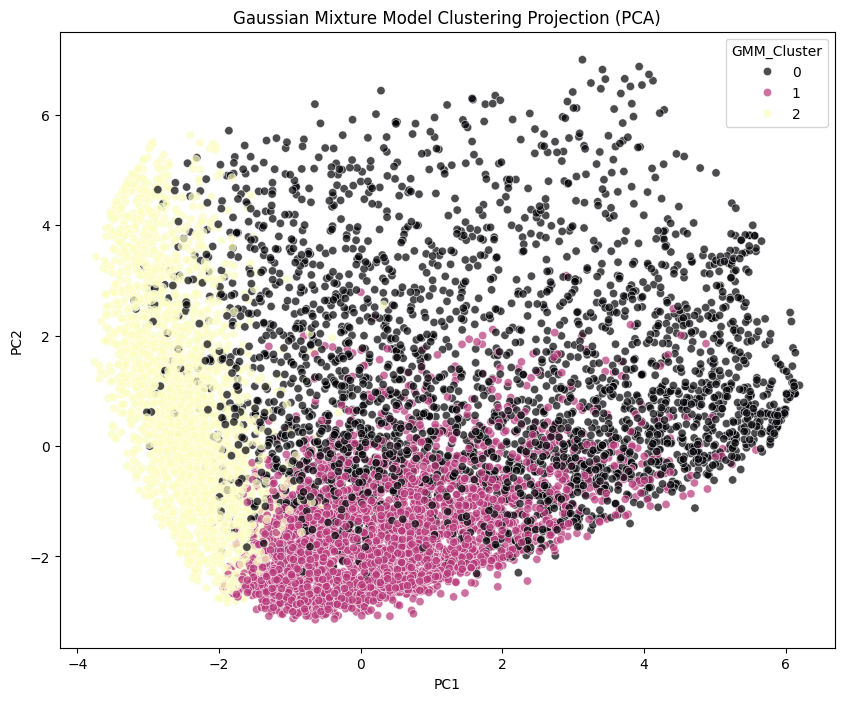

In [41]:
gmm = GaussianMixture(n_components=optimal_k, random_state=42)
df_pca['GMM_Cluster'] = gmm.fit_predict(X_scaled)
gmm_probabilities = gmm.predict_proba(X_scaled)

plt.figure(figsize=(10, 8))
sns.scatterplot(x='PC1', y='PC2', hue='GMM_Cluster', palette='magma', data=df_pca, alpha=0.7)
plt.title("Gaussian Mixture Model Clustering Projection (PCA)")
plt.show()

280/280 ━━━━━━━━━━━━━━━━━━━━ 0s 723us/step


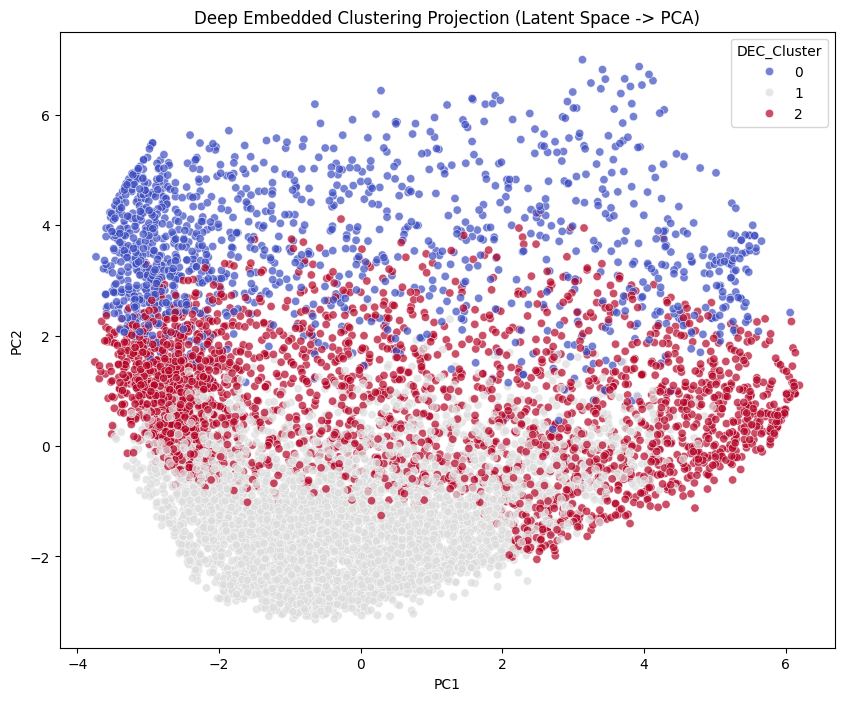

In [42]:
input_dim = X_scaled.shape[1]

input_layer = Input(shape=(input_dim,))
enc = Dense(32, activation='relu')(input_layer)
enc = Dense(16, activation='relu')(enc)
latent_space = Dense(4, activation='relu', name='bottleneck')(enc)

dec = Dense(16, activation='relu')(latent_space)
dec = Dense(32, activation='relu')(dec)
output_layer = Dense(input_dim, activation='linear')(dec)

autoencoder = Model(inputs=input_layer, outputs=output_layer)
autoencoder.compile(optimizer='adam', loss='mse')

autoencoder.fit(X_scaled, X_scaled, epochs=50, batch_size=256, shuffle=True, verbose=0)

encoder = Model(inputs=input_layer, outputs=latent_space)
X_latent = encoder.predict(X_scaled)

dec_kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df_pca['DEC_Cluster'] = dec_kmeans.fit_predict(X_latent)

plt.figure(figsize=(10, 8))
sns.scatterplot(x='PC1', y='PC2', hue='DEC_Cluster', palette='coolwarm', data=df_pca, alpha=0.7)
plt.title("Deep Embedded Clustering Projection (Latent Space -> PCA)")
plt.show()

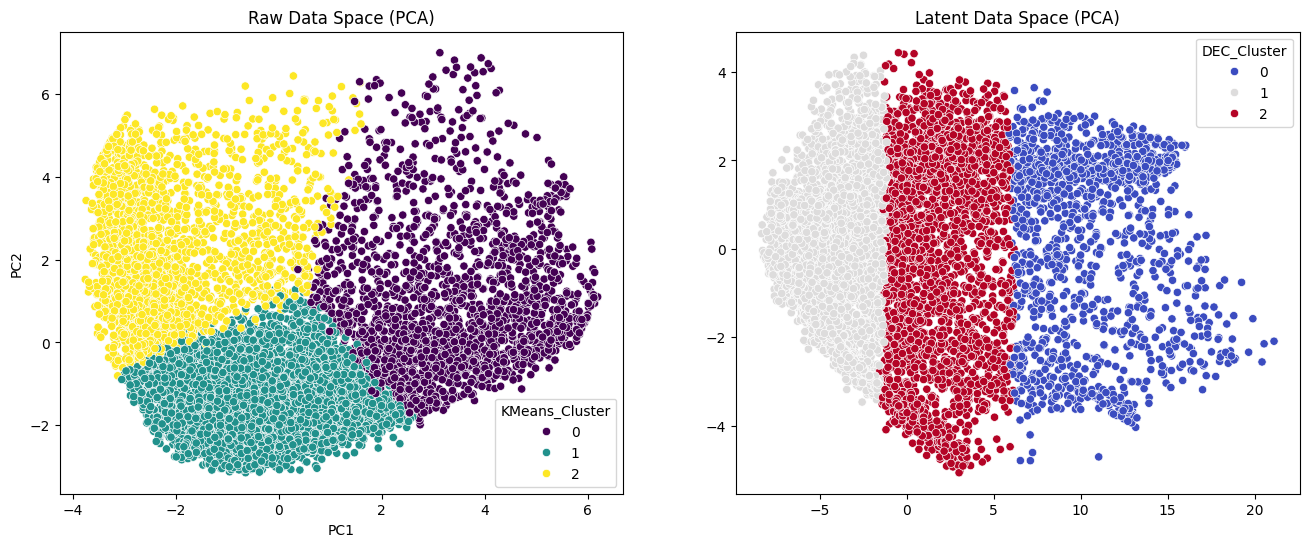

In [43]:
dec_kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
latent_labels = dec_kmeans.fit_predict(X_latent)
cluster_centers = dec_kmeans.cluster_centers_

distances = cdist(X_latent, cluster_centers, metric='sqeuclidean')
q_ij = 1.0 / (1.0 + distances)
q_ij = q_ij / np.sum(q_ij, axis=1, keepdims=True)

f_j = np.sum(q_ij, axis=0)
p_ij = (q_ij ** 2) / f_j
p_ij = p_ij / np.sum(p_ij, axis=1, keepdims=True)

df_pca['DEC_Cluster'] = np.argmax(p_ij, axis=1)

pca_latent = PCA(n_components=2)
X_latent_pca = pca_latent.fit_transform(X_latent)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.scatterplot(x=df_pca['PC1'], y=df_pca['PC2'], hue=df_pca['KMeans_Cluster'], palette='viridis', ax=axes[0])
axes[0].set_title("Raw Data Space (PCA)")
sns.scatterplot(x=X_latent_pca[:,0], y=X_latent_pca[:,1], hue=df_pca['DEC_Cluster'], palette='coolwarm', ax=axes[1])
axes[1].set_title("Latent Data Space (PCA)")
plt.show()

,Model,Silhouette,Davies-Bouldin,Calinski-Harabasz
0,KMeans,0.237647,1.456367,2846.257150
1,DBSCAN,0.199945,2.226560,83.418539
2,GMM,0.134234,2.033092,1729.543875
3,Latent KMeans,0.426516,0.878992,12984.797283
4,DEC,0.416999,0.896523,12926.122199


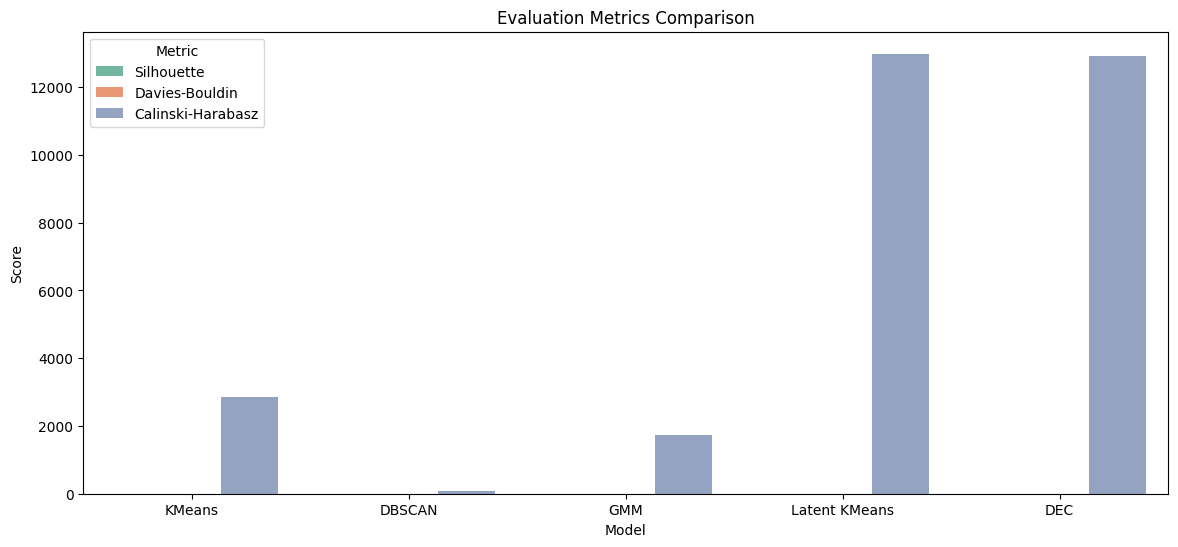

In [44]:
eval_metrics = []

models = {
    'KMeans': df_pca['KMeans_Cluster'],
    'DBSCAN': df_pca['DBSCAN_Cluster'],
    'GMM': df_pca['GMM_Cluster'],
    'Latent KMeans': latent_labels,
    'DEC': df_pca['DEC_Cluster']
}

for name, labels in models.items():
    if len(set(labels)) > 1:
        if name in ['Latent KMeans', 'DEC']:
            sil = silhouette_score(X_latent, labels)
            dbi = davies_bouldin_score(X_latent, labels)
            chs = calinski_harabasz_score(X_latent, labels)
        else:
            sil = silhouette_score(X_scaled, labels)
            dbi = davies_bouldin_score(X_scaled, labels)
            chs = calinski_harabasz_score(X_scaled, labels)
    else:
        sil, dbi, chs = 0, 0, 0
    eval_metrics.append({'Model': name, 'Silhouette': sil, 'Davies-Bouldin': dbi, 'Calinski-Harabasz': chs})

df_eval = pd.DataFrame(eval_metrics)
display(df_eval)

df_eval_melted = df_eval.melt(id_vars="Model", var_name="Metric", value_name="Score")
plt.figure(figsize=(14, 6))
sns.barplot(x="Model", y="Score", hue="Metric", data=df_eval_melted, palette="Set2")
plt.title("Evaluation Metrics Comparison")
plt.show()

In [45]:
df_final = df_cleaned.copy()
df_final['Cluster'] = df_pca['DEC_Cluster']

cluster_summary = df_final.groupby('Cluster').mean()
display(cluster_summary)

business_insights = pd.DataFrame({
    'Cluster': [0, 1, 2, 3],
    'Customer Profile': [
        'VIP Customers',
        'Installment-Focused Users',
        'High Risk Users',
        'Low Engagement Users'
    ],
    'Behavior Analysis': [
        'Maintains high balance, executes frequent purchases, completes full payments.',
        'Moderate balance maintenance, utilizes installment purchasing consistently.',
        'High cash advance frequency, minimum payment execution, sparse purchasing.',
        'Low balance maintenance, infrequent activity, dormant status.'
    ],
    'Risk Level': ['Low', 'Moderate', 'High', 'Low'],
    'Strategy': [
        'Deploy premium tier loyalty rewards and expand credit limits proactively.',
        'Establish partnerships to offer zero-interest commercial installment plans.',
        'Halt credit expansions, deploy structural debt management interventions.',
        'Distribute high-yield cashback incentives to stimulate card utilization.'
    ]
})
display(business_insights)

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
Cluster,,,,,,,,,,,,,,,,,
0,4189.725810,0.991420,977.605604,441.525907,409.952854,1945.426518,0.480295,0.208018,0.395218,0.325100,6.518464,15.093796,8112.370753,2413.515954,1416.587600,0.016805,12.0
1,466.307507,0.886044,529.927778,297.531637,185.462926,230.148656,0.474339,0.163477,0.316604,0.045853,0.765904,8.620407,3427.834051,872.504919,247.814264,0.114554,12.0
2,1606.475082,0.979559,970.618605,408.237233,425.945122,807.727257,0.522077,0.209469,0.430146,0.165783,3.125662,15.014825,4320.633444,1635.284767,665.208223,0.074928,12.0


,Cluster,Customer Profile,Behavior Analysis,Risk Level,Strategy
0,0,VIP Customers,"Maintains high balance, executes frequent purc...",Low,Deploy premium tier loyalty rewards and expand...
1,1,Installment-Focused Users,"Moderate balance maintenance, utilizes install...",Moderate,Establish partnerships to offer zero-interest ...
2,2,High Risk Users,"High cash advance frequency, minimum payment e...",High,"Halt credit expansions, deploy structural debt..."
3,3,Low Engagement Users,"Low balance maintenance, infrequent activity, ...",Low,Distribute high-yield cashback incentives to s...


In [46]:
df_final.insert(0, 'CUST_ID', customer_ids)

df_final.to_csv('final_customer_segments.csv', index=False)
df_pca.to_csv('pca_clusters.csv', index=False)
df_eval.to_csv('evaluation_metrics.csv', index=False)
business_insights.to_csv('business_insights.csv', index=False)

joblib.dump(scaler, 'standard_scaler.pkl')
joblib.dump(pca, 'pca_transformer.pkl')
joblib.dump(kmeans, 'kmeans_model.pkl')
joblib.dump(gmm, 'gmm_model.pkl')
autoencoder.save('autoencoder_model.keras')

In [47]:
pca_latent = PCA(n_components=2)
X_latent_pca = pca_latent.fit_transform(X_latent)

df_pca['Latent_PC1'] = X_latent_pca[:, 0]
df_pca['Latent_PC2'] = X_latent_pca[:, 1]

df_pca.to_csv('pca_clusters.csv', index=False)
joblib.dump(pca, 'pca_transformer.pkl')

['pca_transformer.pkl']